<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Identification-of-Co-expressed-Genes-using-Unsupervised-Machine-Learning/blob/main/Identification_of_Co_expressed_Genes_using_Unsupervised_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
import os

os.listdir()

['.config', 'SC_expression.csv', 'sample_data']

In [3]:
df = pd.read_csv("SC_expression.csv")

In [4]:
df.head()

,Unnamed: 0,IFFABF,SAASCC,IFFAFF,IFFAFA,INICIA,INICIF,SAABQI,FFNAAA,IFAAAR,...,SAABIQ,AFNAQI,SAANNN,IFFABB,FFNARS,SAABQF,IFFAFS,IFAAAA.1,IFFAFI,SARIAI
0,YAL008W,70.804931,30.970186,118.384653,110.703950,74.102235,89.802220,7.341536,112.091167,5.973668,...,12.953973,1.638143,34.066051,81.346495,127.981129,14.649997,101.586667,6.574096,110.284505,1.489269
1,YBR255W,36.368786,16.860290,27.726452,34.527928,35.440199,56.971301,15.452185,26.858749,5.384088,...,21.543401,3.547613,28.997105,35.137835,31.181031,13.574768,30.903387,6.459673,29.086023,5.119361
2,YGR164W,0.351389,0.904239,0.456027,0.292610,0.000000,1.103560,0.769113,18.085545,0.711946,...,1.222073,0.712236,0.904559,0.000000,2.586445,1.209633,0.082190,0.977793,0.100993,0.046540
3,YGR131W,7.379174,5.858715,12.130323,12.679748,11.276427,18.484635,2.377259,22.251591,4.405163,...,2.199731,0.491782,11.025385,7.059656,21.936885,2.016055,9.369644,4.691325,12.018183,0.930793
4,YNL003C,82.049386,78.480411,67.218405,64.179030,75.713153,75.317991,20.136785,43.326887,30.324430,...,21.124404,4.232717,131.212325,84.715876,41.766297,17.539675,66.162837,26.712465,75.239886,3.909330


In [5]:
df.shape

(2531, 93)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2531 entries, 0 to 2530
Data columns (total 93 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2531 non-null   object 
 1   IFFABF      2531 non-null   float64
 2   SAASCC      2531 non-null   float64
 3   IFFAFF      2531 non-null   float64
 4   IFFAFA      2531 non-null   float64
 5   INICIA      2531 non-null   float64
 6   INICIF      2531 non-null   float64
 7   SAABQI      2531 non-null   float64
 8   FFNAAA      2531 non-null   float64
 9   IFAAAR      2531 non-null   float64
 10  AFIINC      2531 non-null   float64
 11  IFFABN      2531 non-null   float64
 12  SAARRS      2531 non-null   float64
 13  FFNARN      2531 non-null   float64
 14  SAABQR      2531 non-null   float64
 15  FFNAAR      2531 non-null   float64
 16  FAFASB      2531 non-null   float64
 17  SAABBN      2531 non-null   float64
 18  SAASCF      2531 non-null   float64
 19  INICIQ      2531 non-null  

In [7]:
df.describe()

,IFFABF,SAASCC,IFFAFF,IFFAFA,INICIA,INICIF,SAABQI,FFNAAA,IFAAAR,AFIINC,...,SAABIQ,AFNAQI,SAANNN,IFFABB,FFNARS,SAABQF,IFFAFS,IFAAAA.1,IFFAFI,SARIAI
count,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000,2531.000000,...,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000,2530.000000
mean,135.476412,101.030378,135.841035,136.079477,118.586108,125.433352,36.901278,51.838532,66.208567,14.933413,...,34.736393,15.813382,102.308307,134.977433,59.657332,38.986088,136.669198,61.819579,136.379375,4.426141
std,584.719341,532.613581,690.259760,658.316551,615.570903,532.474286,169.897189,268.471061,702.929965,101.869433,...,152.450753,99.760970,498.205210,578.330596,327.921267,212.165981,687.183512,526.304788,661.881552,10.086262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.168254,11.755107,22.983769,24.676740,14.498263,22.898876,8.390327,7.449872,4.560901,1.379294,...,9.401233,1.500783,15.697520,26.313265,7.855129,7.459402,22.869329,5.258236,24.036366,1.489269
50%,48.052478,31.215084,42.684143,46.037237,35.440199,51.039664,17.759525,15.389867,11.980709,3.633676,...,19.081797,3.986826,38.401110,50.300051,16.285024,16.195639,42.862012,13.429047,44.790456,3.304315
75%,96.104956,73.733156,87.739627,91.391719,85.378662,103.941586,32.442598,31.245351,30.107510,8.902975,...,33.895067,9.675386,85.340066,97.511503,34.138679,30.946439,88.539027,32.693644,91.070561,5.677837
max,24928.167256,18323.367552,28758.167789,27785.228484,25710.253816,20573.536845,7774.546880,10947.586964,31230.514662,3624.690061,...,7071.926781,3218.275459,15781.354118,24643.334930,12822.061494,9442.191951,28465.964891,22129.207550,28179.508836,435.192218


In [8]:
# Rename the first column
df.rename(columns={'Unnamed: 0': 'Gene_ID'}, inplace=True)

# Check missing values
print(df.isnull().sum().sum())

# Check duplicate genes
print("Duplicate genes:", df['Gene_ID'].duplicated().sum())

39
Duplicate genes: 0


In [9]:
df.fillna(df.median(numeric_only=True), inplace=True)

# Verify
print(df.isnull().sum().sum())

0


In [10]:
gene_ids = df['Gene_ID']

expression_data = df.drop('Gene_ID', axis=1)

expression_data.head()

,IFFABF,SAASCC,IFFAFF,IFFAFA,INICIA,INICIF,SAABQI,FFNAAA,IFAAAR,AFIINC,...,SAABIQ,AFNAQI,SAANNN,IFFABB,FFNARS,SAABQF,IFFAFS,IFAAAA.1,IFFAFI,SARIAI
0,70.804931,30.970186,118.384653,110.703950,74.102235,89.802220,7.341536,112.091167,5.973668,1.599944,...,12.953973,1.638143,34.066051,81.346495,127.981129,14.649997,101.586667,6.574096,110.284505,1.489269
1,36.368786,16.860290,27.726452,34.527928,35.440199,56.971301,15.452185,26.858749,5.384088,3.205522,...,21.543401,3.547613,28.997105,35.137835,31.181031,13.574768,30.903387,6.459673,29.086023,5.119361
2,0.351389,0.904239,0.456027,0.292610,0.000000,1.103560,0.769113,18.085545,0.711946,0.614063,...,1.222073,0.712236,0.904559,0.000000,2.586445,1.209633,0.082190,0.977793,0.100993,0.046540
3,7.379174,5.858715,12.130323,12.679748,11.276427,18.484635,2.377259,22.251591,4.405163,0.467589,...,2.199731,0.491782,11.025385,7.059656,21.936885,2.016055,9.369644,4.691325,12.018183,0.930793
4,82.049386,78.480411,67.218405,64.179030,75.713153,75.317991,20.136785,43.326887,30.324430,3.650576,...,21.124404,4.232717,131.212325,84.715876,41.766297,17.539675,66.162837,26.712465,75.239886,3.909330


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(expression_data)

scaled_data.shape

(2531, 92)

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,-0.746681,-0.353903
1,-1.138983,-0.082821
2,-1.736368,0.074561
3,-1.412484,-0.069637
4,-0.720220,-0.161458


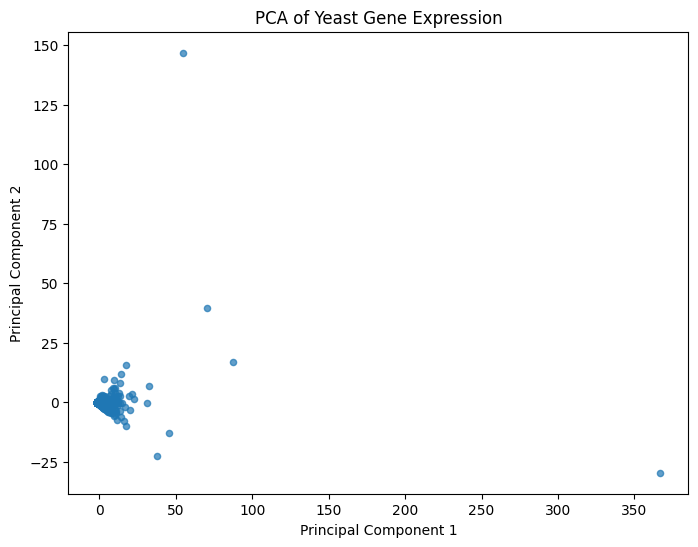

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    s=20,
    alpha=0.7
)

plt.title('PCA of Yeast Gene Expression')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [14]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

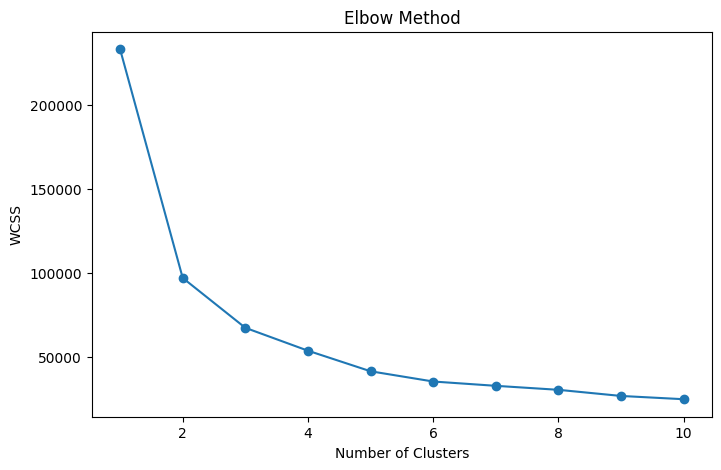

In [15]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

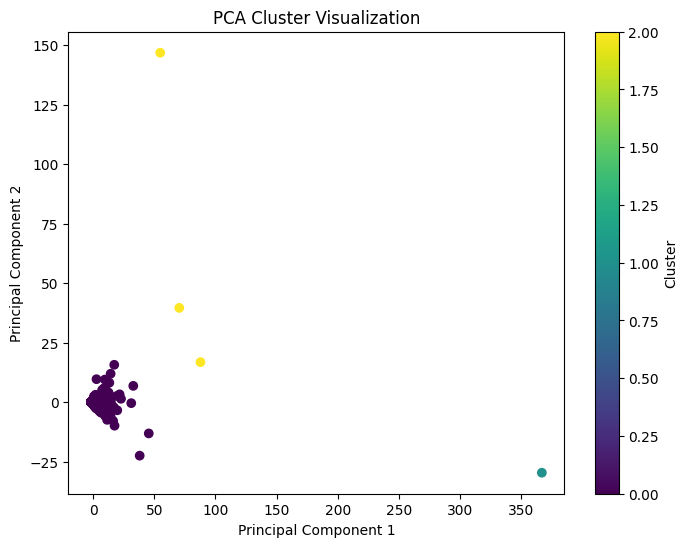

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


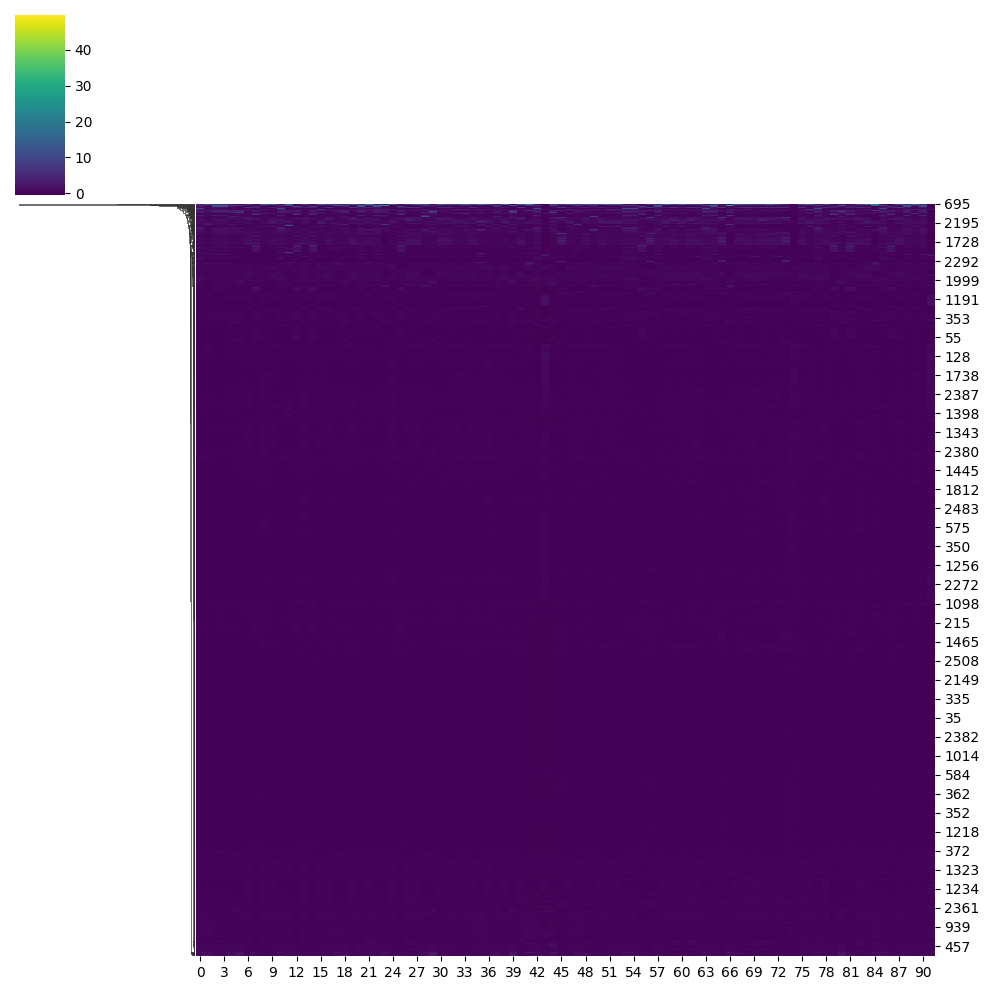

In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clustering (Use 'scaled_data' as you did before)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# 2. PCA Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis')
plt.title('PCA Cluster Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

# 4. Heatmap
# Assuming 'scaled_data' is a DataFrame or convertible to one
import pandas as pd
df_scaled = pd.DataFrame(scaled_data)
sns.clustermap(df_scaled, row_cluster=True, col_cluster=False, cmap='viridis')

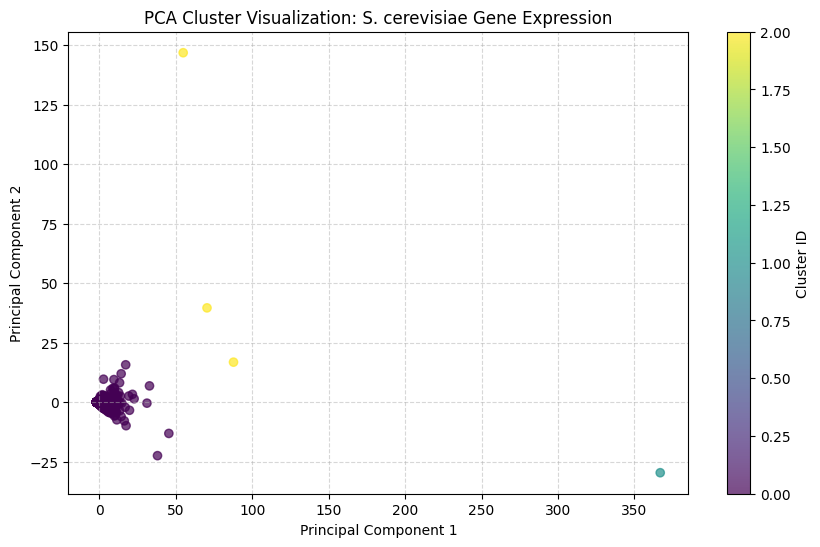

In [19]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Apply K-Means Clustering (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# 2. PCA for Dimensionality Reduction
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# 3. Plotting
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.title('PCA Cluster Visualization: S. cerevisiae Gene Expression')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

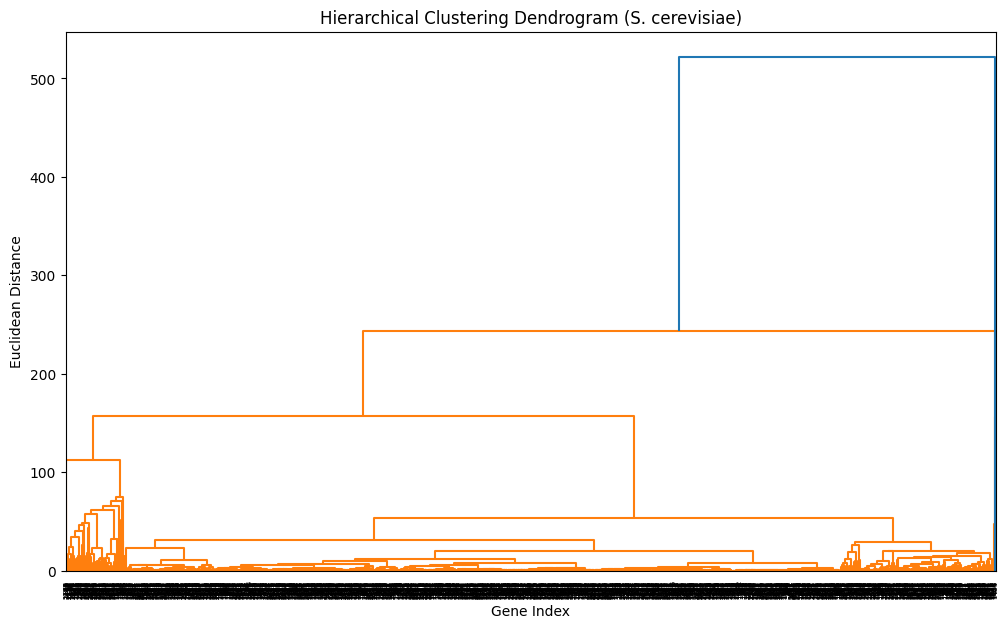

In [20]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Perform Hierarchical Clustering
# 'ward' method is generally best for minimizing variance within clusters
linked = linkage(scaled_data, method='ward')

# 2. Plot the Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(linked,
            orientation='top',
            distance_sort='descending',
            show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (S. cerevisiae)')
plt.xlabel('Gene Index')
plt.ylabel('Euclidean Distance')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


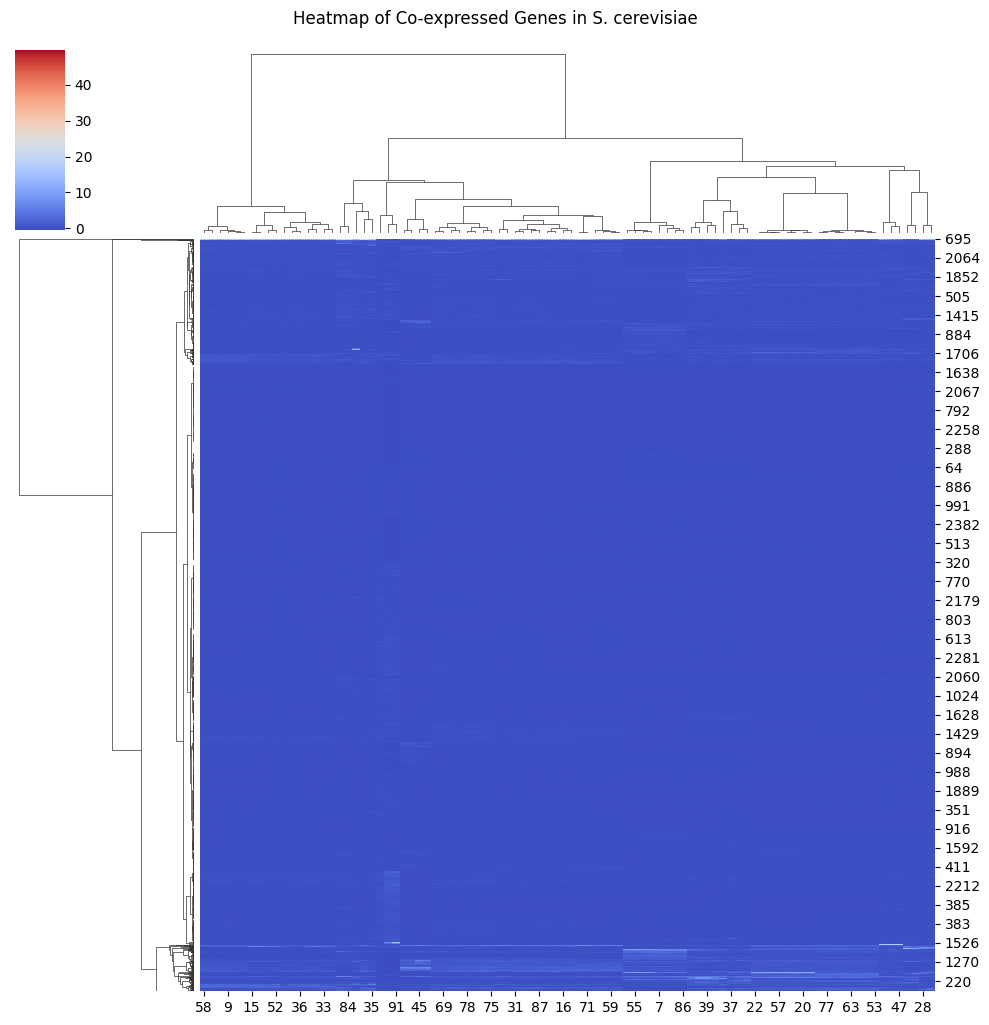

In [21]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure data is in a DataFrame format
# If your original CSV had gene names, replace the index with them
df_plot = pd.DataFrame(scaled_data)

# 2. Generate the Clustermap
# cmap='vlag' or 'coolwarm' are standard for expression data (diverging colors)
g = sns.clustermap(df_plot,
                   method='ward',
                   metric='euclidean',
                   cmap='coolwarm',
                   standard_scale=None,
                   figsize=(10, 10))

g.fig.suptitle('Heatmap of Co-expressed Genes in S. cerevisiae', y=1.02)
plt.show()

In [23]:
# Use the column name that contains your gene IDs (e.g., 'Gene_Name')
# If the genes are the index, use df.index
gene_names = df.iloc[:, 0].values  # Gets the first column

# Now create the DataFrame
cluster_df = pd.DataFrame({'Gene_ID': gene_names, 'Cluster': clusters})

In [24]:
print(df.head())
print(df.columns)

   Gene_ID     IFFABF     SAASCC      IFFAFF      IFFAFA     INICIA  \
0  YAL008W  70.804931  30.970186  118.384653  110.703950  74.102235   
1  YBR255W  36.368786  16.860290   27.726452   34.527928  35.440199   
2  YGR164W   0.351389   0.904239    0.456027    0.292610   0.000000   
3  YGR131W   7.379174   5.858715   12.130323   12.679748  11.276427   
4  YNL003C  82.049386  78.480411   67.218405   64.179030  75.713153   

      INICIF     SAABQI      FFNAAA     IFAAAR  ...     SAABIQ    AFNAQI  \
0  89.802220   7.341536  112.091167   5.973668  ...  12.953973  1.638143   
1  56.971301  15.452185   26.858749   5.384088  ...  21.543401  3.547613   
2   1.103560   0.769113   18.085545   0.711946  ...   1.222073  0.712236   
3  18.484635   2.377259   22.251591   4.405163  ...   2.199731  0.491782   
4  75.317991  20.136785   43.326887  30.324430  ...  21.124404  4.232717   

       SAANNN     IFFABB      FFNARS     SAABQF      IFFAFS   IFAAAA.1  \
0   34.066051  81.346495  127.981129  14.6

In [26]:
# 1. Extract the gene names using the correct column header
gene_names = df['Gene_ID'].values

# 2. Create the DataFrame linking genes to their assigned clusters
cluster_df = pd.DataFrame({'Gene_ID': gene_names, 'Cluster': clusters})

# 3. Export to CSV for your records
cluster_df.to_csv('gene_clusters.csv', index=False)

# 4. Preview the mapping to verify
print(cluster_df.head())

   Gene_ID  Cluster
0  YAL008W        0
1  YBR255W        0
2  YGR164W        0
3  YGR131W        0
4  YNL003C        0
